# Name: Dishap Shrestha
# ID: 2409012

# Building an End-to-End Image Classifier with CNNs.

Imports

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

## Data Understanding and Visualizations.

### Verify Dataset.

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Sem 6/AI/Week 5/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/Sem 6/AI/Week 6/fruits"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [ ]:
import os
train_dir = os.path.join(extract_path, "FruitinAmazon/train")
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Check for corrupted files.

In [ ]:
from PIL import Image, UnidentifiedImageError
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path): # Ensure it’s a valid directory
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify() # Verify image integrity
      except (IOError, UnidentifiedImageError):
        corrupted_images.append(img_path)
# Print results
if corrupted_images:
  print("\nCorrupted Images Found:")
  for img in corrupted_images:
    print(img)
else:
  print("\nNo corrupted images found.")


No corrupted images found.


### Class Count Balance

In [ ]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


### Select Random Images for Visualization

In [ ]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

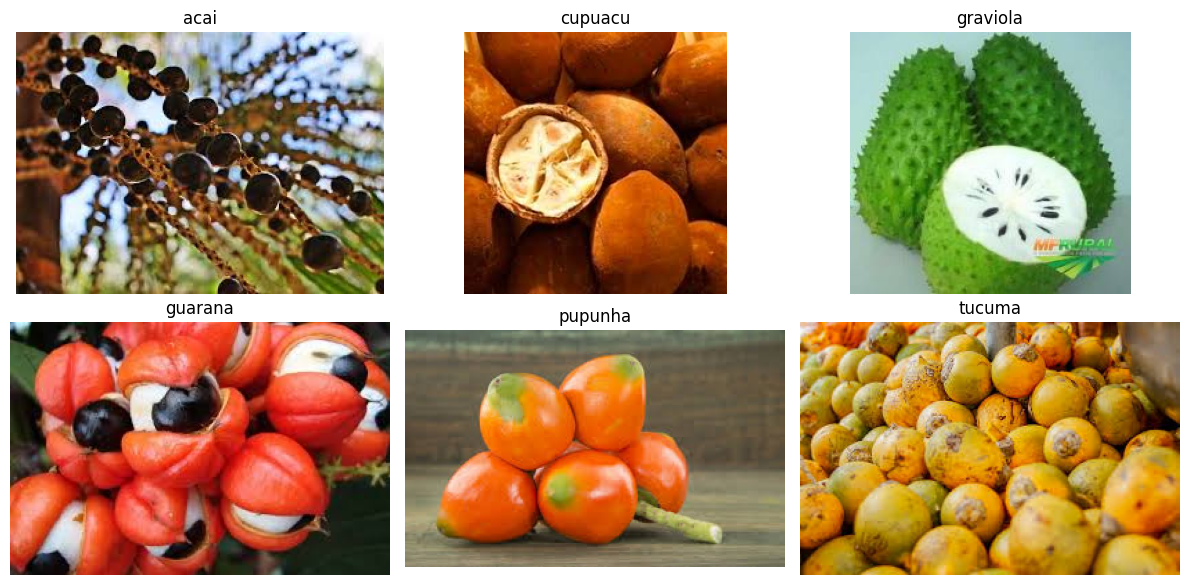

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

## Data Generation and Pre processing

In [ ]:
image_size = (128, 128)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="both",
  seed=1337,
  image_size=image_size,
  batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [ ]:
for images, labels in train_ds.take(1): # Take one batch
  print("Images shape:", images.shape)
  print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


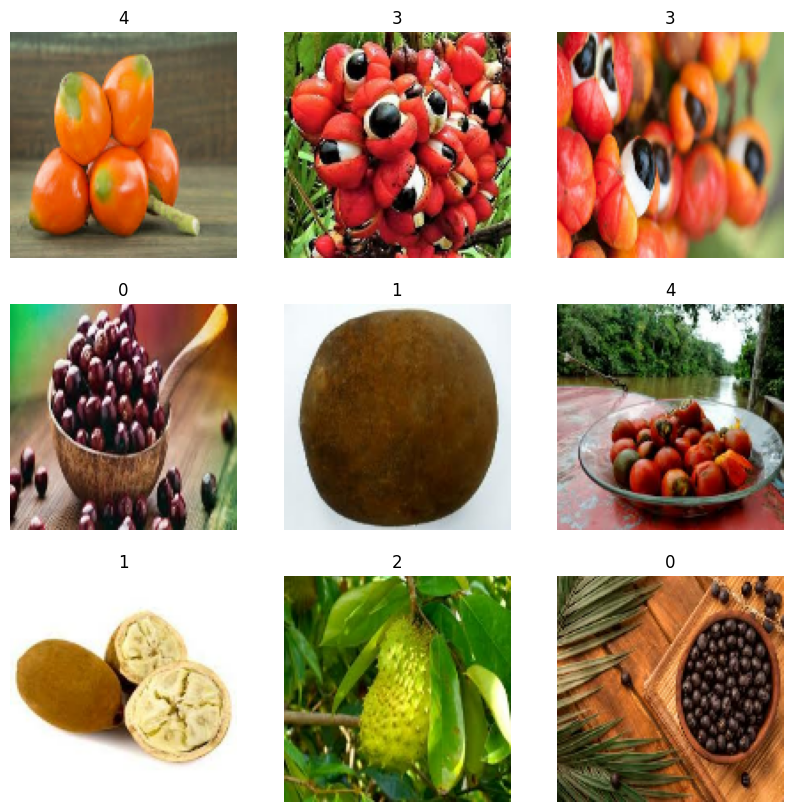

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Takes one batch of images from the dataset (train_ds).
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(images[i]).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

## Data Augmentation with Keras.

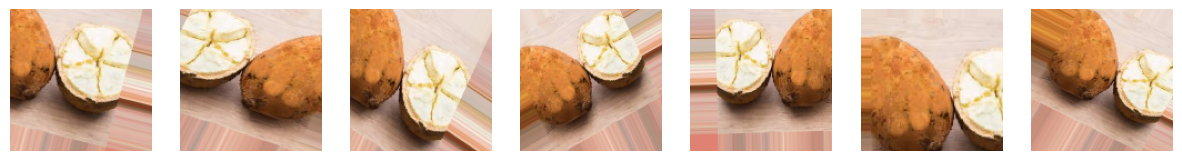

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
  rotation_range=30, # Rotate images by up to 30 degrees
  width_shift_range=0.2, # Shift width by 20%
  height_shift_range=0.2, # Shift height by 20%
  shear_range=0.2, # Shear transformation
  zoom_range=0.2, # Zoom in/out by 20%
  horizontal_flip=True, # Flip images horizontally
  fill_mode='nearest' # Fill in missing pixels
)

# Load an example image
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
img = image.load_img('/content/drive/MyDrive/Sem 6/AI/Week 6/fruits/FruitinAmazon/test/cupuacu/download (2).jpeg', target_size=(128, 128))
x = image.img_to_array(img) # Convert to NumPy array
x = np.expand_dims(x, axis=0)
# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)
# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))
for i in range(7):
  batch = next(aug_iter)
  ax[i].imshow(batch[0].astype('uint8'))
  ax[i].axis('off')
plt.show()

In [ ]:
# This is a sample implementation, Thus I only use two augmentation, you can use more than two
# augmentation type for your project. Please check keras documentations for other available
# augmentation techniques.
data_augmentation_layers = [
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
]
def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images

In [ ]:
model = keras.Sequential([
  layers.Input(shape=(128, 128, 3)),
  *data_augmentation_layers, # Include augmentation before the model layers
  layers.Conv2D(32, (3,3), activation="relu"),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(10, activation="softmax")
])

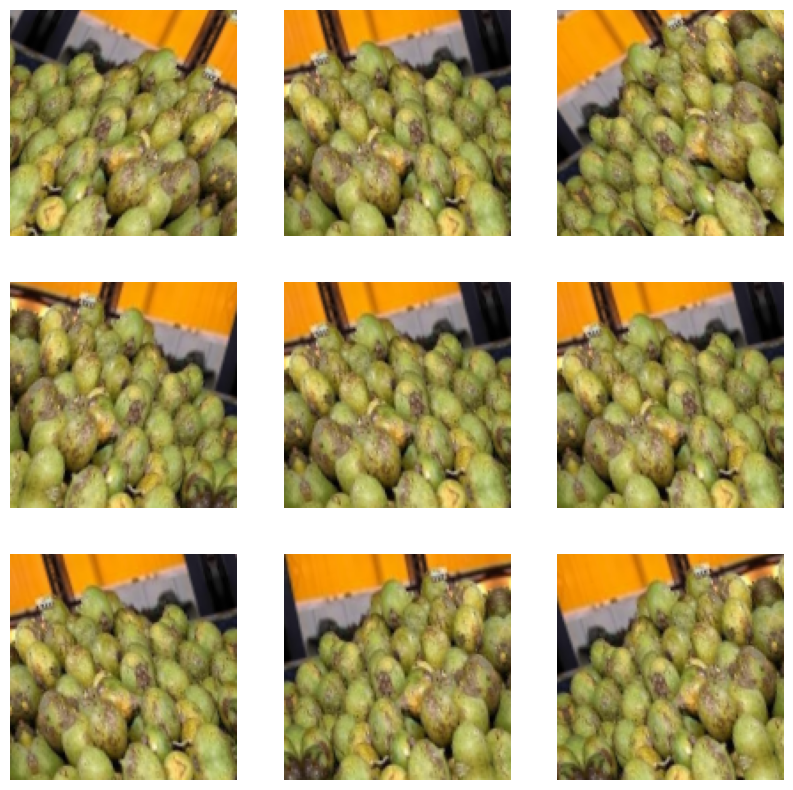

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(augmented_images[0]).astype("uint8"))
    plt.axis("off")

## Data Pre - Processing

In [ ]:
augmented_train_ds = train_ds.map( lambda x, y: (data_augmentation(x), y))

In [ ]:
input_shape = (128, 128, 3)

inputs = keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(32, (3,3), activation="relu")(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [ ]:
# img_height = 128
# img_width = 128
# batch_size = 32
# validation_split = 0.2

# rescale = tf.keras.layers.Rescaling(1./255)

# train_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     train_dir,
#     validation_split=validation_split,
#     subset="training",
#     seed=123,
#     image_size=(img_height, img_width),
#     batch_size=batch_size
# )

# val_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     train_dir,
#     validation_split=validation_split,
#     subset="validation",
#     seed=123,
#     image_size=(img_height, img_width),
#     batch_size=batch_size
# )

# train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# val_ds = val_ds.map(lambda x, y: (rescale(x), y))

In [ ]:
model.compile(
  optimizer=keras.optimizers.Adam(1e-3),
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"],
)

# Callbacks for saving the best model and early stopping
callbacks = [
  ModelCheckpoint("save_at_epoch_{epoch}.keras"),
  EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# Train the model
epochs = 50  # You can adjust the number of epochs
model.fit(
  train_ds,
  epochs=epochs,
  callbacks=callbacks,
  validation_data=val_ds,
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 782ms/step - accuracy: 0.1389 - loss: 13.8362 - val_accuracy: 0.1667 - val_loss: 26.3494
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 0.2500 - loss: 14.1954 - val_accuracy: 0.2222 - val_loss: 13.0242
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.2083 - loss: 11.7307 - val_accuracy: 0.2222 - val_loss: 12.0719
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 359ms/step - accuracy: 0.2361 - loss: 10.2353 - val_accuracy: 0.1111 - val_loss: 12.1262
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 368ms/step - accuracy: 0.3056 - loss: 8.8807 - val_accuracy: 0.2778 - val_loss: 7.6466
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 0.3333 - loss: 5.2910 - val_accuracy: 0.2222 - val_loss: 2.8428
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.4722 - loss: 2.0056 - val_accuracy: 0.3889 - val_loss: 2.1893
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step - accuracy: 0.5000 - loss: 1.5775 - val_accuracy: 0.4444 - v

### Model Building

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Define a simple CNN model
model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)), # Corrected input_shape
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation="relu"),
  layers.Dense(len(class_names), activation="softmax") # Corrected number of classes
])
# Compile the model
model.compile(optimizer="adam",
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"]
)

# Train the model
model.fit(train_ds, epochs=5, batch_size=32, validation_data=val_ds)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.0694 - loss: 933.4210 - val_accuracy: 0.1667 - val_loss: 1071.4777
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 616ms/step - accuracy: 0.2222 - loss: 546.4832 - val_accuracy: 0.2778 - val_loss: 260.1488
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 0.5278 - loss: 127.5878 - val_accuracy: 0.2222 - val_loss: 61.9461
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 0.7222 - loss: 14.2544 - val_accuracy: 0.5000 - val_loss: 9.7391
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 569ms/step - accuracy: 0.6667 - loss: 2.7819 - val_accuracy: 0.2778 - val_loss: 3.9807


In [ ]:
from tensorflow.keras.layers import BatchNormalization
layer = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
beta_initializer="zeros", gamma_initializer="ones")

In [ ]:
from tensorflow.keras.layers import Dropout
layer = Dropout(0.5, noise_shape=None, seed=None)

# Task 1

In [ ]:
data_augmentation_layers = [
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
]

def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images
# Define the model using the Sequential API with a list of layers
model = keras.Sequential([
  # Data augmentation applied using Lambda layer
  layers.Lambda(data_augmentation, input_shape=(128, 128, 3)), # Corrected input_shape
  # Rescaling layer to normalize pixel values
  layers.Rescaling(1./255),
  # First Convolutional Block
  layers.Conv2D(32, (3, 3), padding='same', activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  layers.MaxPooling2D((2, 2)),
  Dropout(0.25),
  # Second Convolutional Block
  layers.Conv2D(64, (3, 3), padding='same', activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  layers.MaxPooling2D((2, 2)),
  Dropout(0.25),
  # Third Convolutional Block
  layers.Conv2D(128, (3, 3), padding='same', activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  layers.MaxPooling2D((2, 2)),
  Dropout(0.25),
  # Fourth Convolutional Block
  layers.Conv2D(256, (3, 3), padding='same', activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  layers.MaxPooling2D((2, 2)),
  Dropout(0.25),
  # Flatten the output of the last Conv2D layer
  layers.Flatten(),
  # First Fully Connected Layer
  layers.Dense(512, activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  Dropout(0.5),
  # Second Fully Connected Layer
  layers.Dense(256, activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  Dropout(0.5),
  # Third Fully Connected Layer
  layers.Dense(128, activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  Dropout(0.5),
  # Fourth Fully Connected Layer
  layers.Dense(64, activation=None),
  BatchNormalization(),
  layers.Activation('relu'),
  Dropout(0.5),
  # Output Layer with len(class_names) neurons (for classification task with 6 classes)
  layers.Dense(len(class_names), activation='softmax') # Corrected number of classes
])
# Compile the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy as the metric
model.compile(optimizer='adam',

loss='sparse_categorical_crossentropy', # Use this for integer labels
metrics=['accuracy'])

# Summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:
model.fit(train_ds, epochs=5, batch_size=32, validation_data=val_ds)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1806 - loss: 2.4593 - val_accuracy: 0.1111 - val_loss: 1.7986
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1806 - loss: 2.2852 - val_accuracy: 0.2778 - val_loss: 1.7988
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.1944 - loss: 2.3227 - val_accuracy: 0.1111 - val_loss: 1.8130
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1667 - loss: 2.4559 - val_accuracy: 0.0556 - val_loss: 1.8155
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2083 - loss: 2.3119 - val_accuracy: 0.1111 - val_loss: 1.8188


# Image Classification via fine-tuning with VGG16

In [ ]:
image_size = (224, 224)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="both",
  seed=1337,
  image_size=image_size,
  batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


## 1. Load the Pre - trained Model:

In [ ]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

## 2. Freeze the Layers:

In [ ]:
# Freeze the layers of the base model
for layer in base_model.layers:
  layer.trainable = False

## 3. Add a Custom Layers:

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
# The final output layer will be added in the next step (cell 1FO1s-LOtO-M)

## 4. Create the Final Model:

In [ ]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

## 5. Compile and Fit the model.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Get the number of classes from class_names
num_classes_vgg = len(class_names)

# Add the final output layer with the correct number of classes
predictions = Dense(num_classes_vgg, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# One-hot encode the labels for categorical_crossentropy
# Get the number of classes from the dataset (assuming labels are 0-indexed)
num_classes = len(class_names)

def one_hot_encode(image, label):
    return image, tf.one_hot(label, num_classes)

train_ds_one_hot = train_ds.map(one_hot_encode)
val_ds_one_hot = val_ds.map(one_hot_encode)


# Train the model
epochs = 10 # You can adjust the number of epochs
model.fit(
    train_ds_one_hot,
    epochs=epochs,
    validation_data=val_ds_one_hot,
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 18s/step - accuracy: 0.2361 - loss: 7.1984 - val_accuracy: 0.2222 - val_loss: 4.7270
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 0.6667 - loss: 2.6524 - val_accuracy: 0.3333 - val_loss: 10.0237
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 18s/step - accuracy: 0.7778 - loss: 1.6514 - val_accuracy: 0.3889 - val_loss: 8.6735
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 23s/step - accuracy: 0.9583 - loss: 0.2150 - val_accuracy: 0.2778 - val_loss: 11.7149
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 0.8472 - loss: 0.4330 - val_accuracy: 0.4444 - val_loss: 6.9279
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.5556 - val_loss: 5.3276
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 23s/step - accuracy: 1.0000 - loss: 6.7660e-05 - val_accuracy: 0.6111 - val_loss: 5.0102
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 1.0000 - loss: 2.7515e-04 - val_accuracy: 0.6111 - val_los

### Model Evaluation and Classification Report

In [ ]:
loss, accuracy = model.evaluate(val_ds_one_hot)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.6111 - loss: 5.8895
Validation Loss: 5.8895
Validation Accuracy: 0.6111


In [ ]:
from sklearn.metrics import classification_report

# Get true labels and predicted labels for the validation set
y_true = np.concatenate([y.numpy() for x, y in val_ds_one_hot], axis=0)
y_pred_probabilities = model.predict(val_ds_one_hot)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Assuming y_true is one-hot encoded, convert it to class indices
y_true_indices = np.argmax(y_true, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_indices, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step

Classification Report:
              precision    recall  f1-score   support

        acai       1.00      0.33      0.50         3
     cupuacu       1.00      1.00      1.00         4
    graviola       0.33      1.00      0.50         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.38      0.75      0.50         4
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.61        18
   macro avg       0.62      0.58      0.51        18
weighted avg       0.77      0.61      0.60        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Performance Comparison

Let's compare the performance of the VGG16 fine-tuned model with the previously trained models:

**1. Simple CNN Model (Cell `7854047f`):**
*   **Validation Accuracy:** The last epoch's validation accuracy was `0.6111` with a validation loss of `1.7402` (Epoch 18/50, early stopped).

**2. Custom CNN Model with Data Augmentation, Batch Normalization, and Dropout (Cell `7UxxInnQidgF`):**
*   **Validation Accuracy:** The last epoch's validation accuracy was `0.1111` with a validation loss of `1.8188` (Epoch 5/5).

**3. VGG16 Fine-tuned Model (current evaluation after architecture fix):**
*   **Validation Accuracy:** `0.6111` (Epoch 10/10)
*   **Validation Loss:** `5.8895` (Epoch 10/10)

Based on these results, we can determine if fine-tuning with VGG16 led to an improvement in performance. Typically, transfer learning with pre-trained models like VGG16 is expected to yield better results, especially with limited datasets, due to the rich feature extraction capabilities learned from large datasets like ImageNet.